In [1]:
#imoprt libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load data
diamonds = pd.read_csv("diamonds.csv")

In [3]:
#data analysis
diamonds_sum = diamonds.describe()
diamonds_info = diamonds.info()
diamonds_missing = diamonds.isnull().sum()

#display
diamonds_info
diamonds_missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   x           53940 non-null  float64
 8   y           53940 non-null  float64
 9   z           53940 non-null  float64
 10  price       53940 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
x             0
y             0
z             0
price         0
dtype: int64

In [4]:
#display anaylsis
diamonds_sum

,Unnamed: 0,carat,depth,table,x,y,z,price
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734,3932.799722
std,15571.281097,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699,3989.439738
min,1.000000,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,13485.750000,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,26970.500000,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,40455.250000,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.250000
max,53940.000000,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


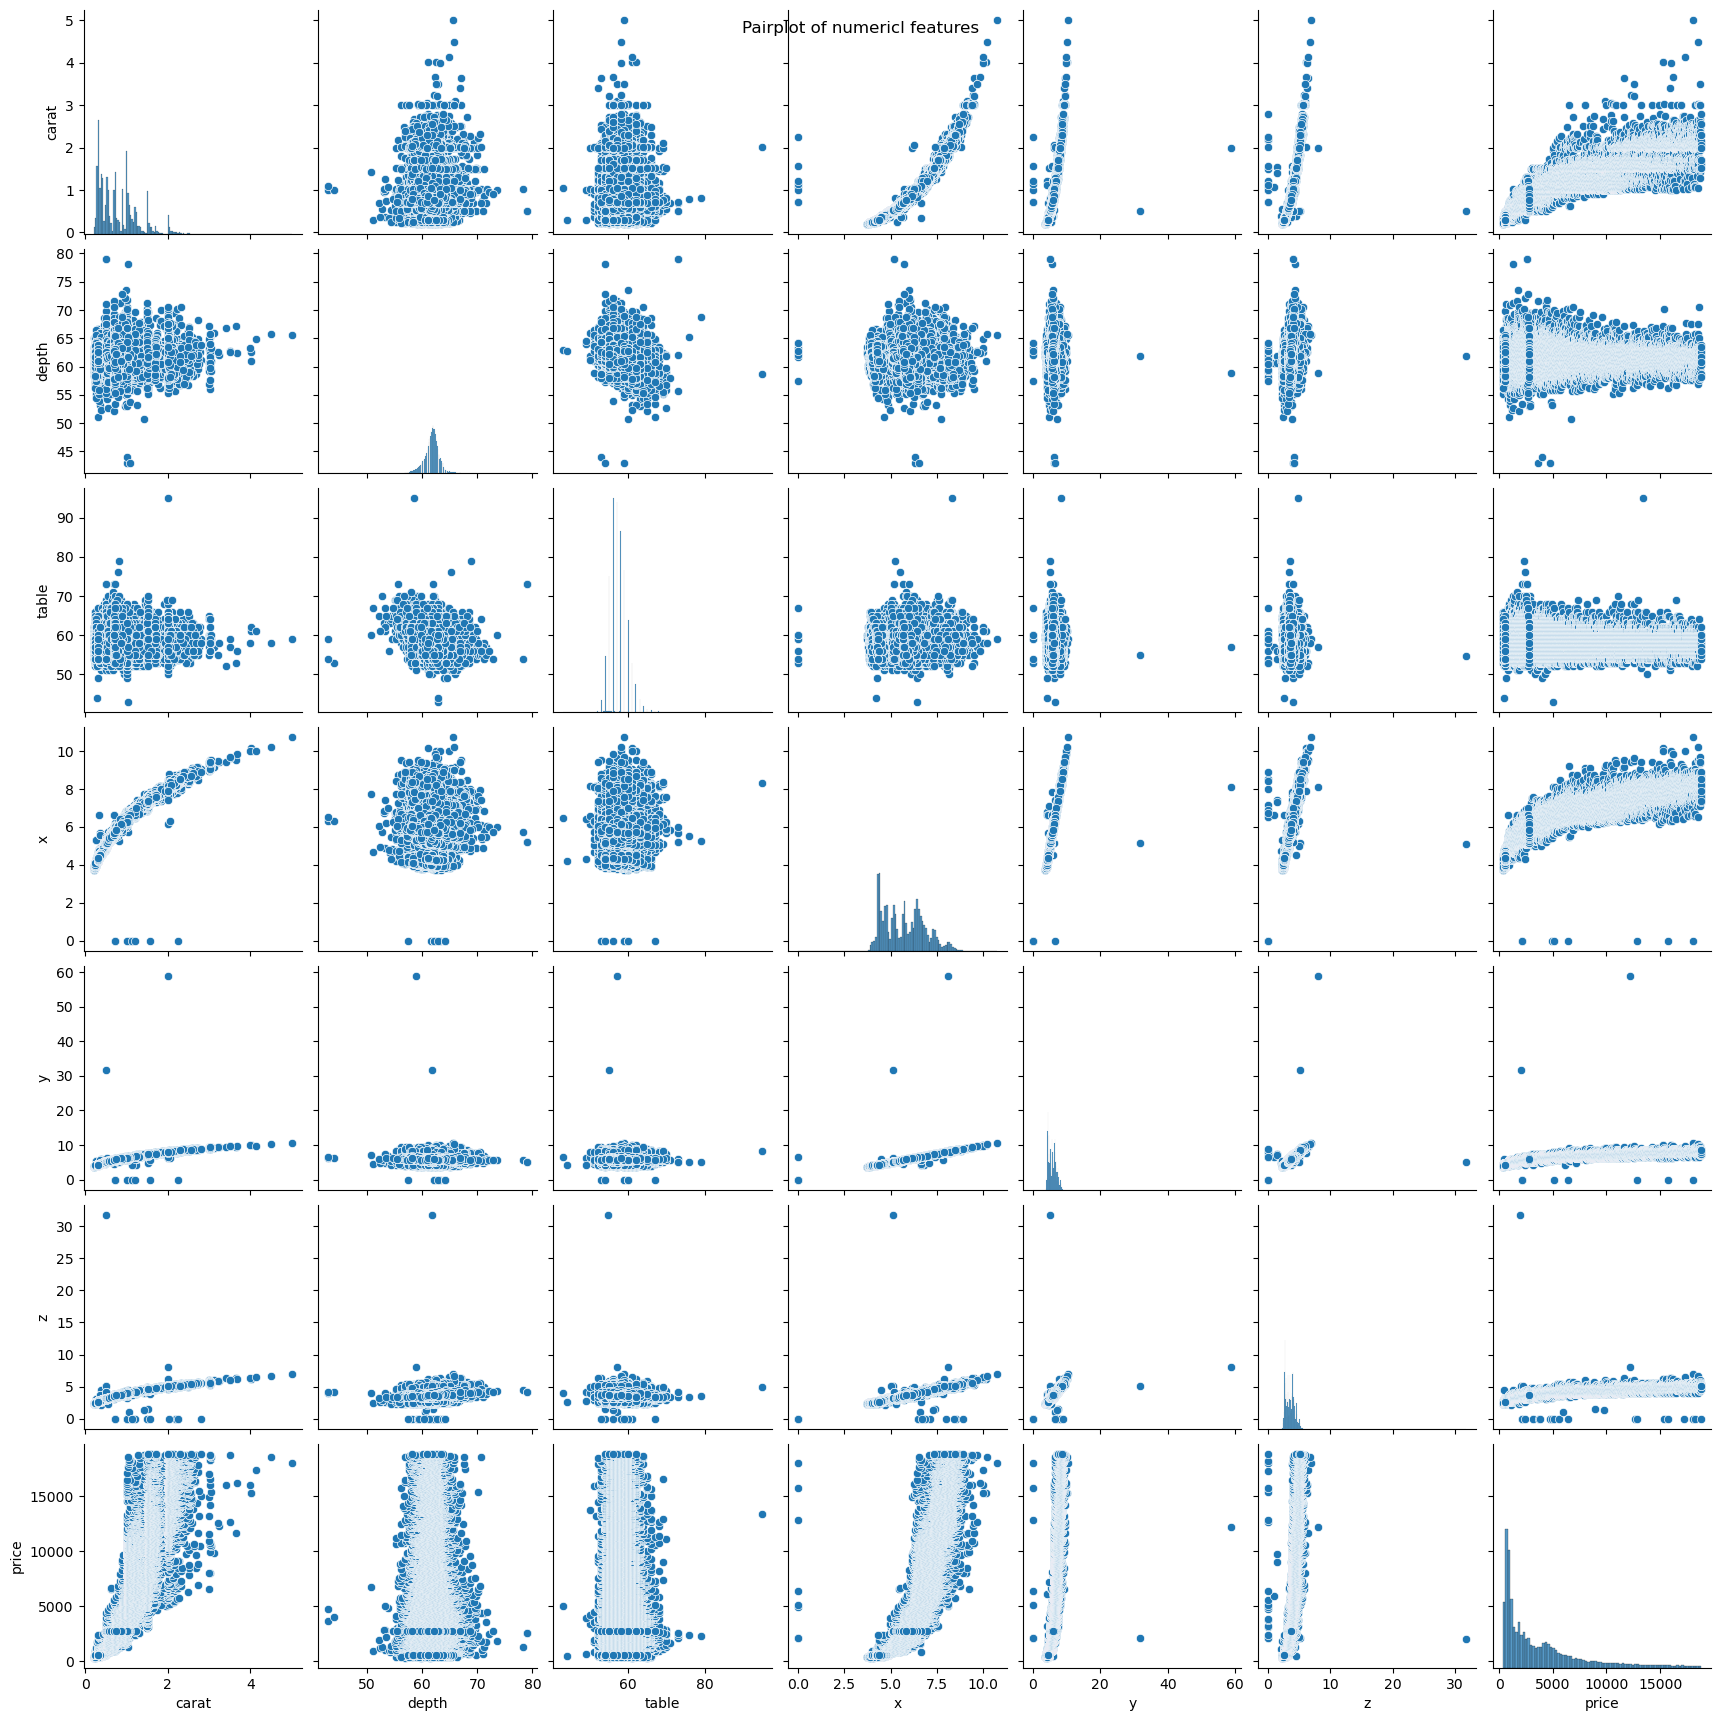

In [5]:
#EDA
sns.pairplot(diamonds[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']])
plt.suptitle("Pairplot of numericl features")
plt.show()

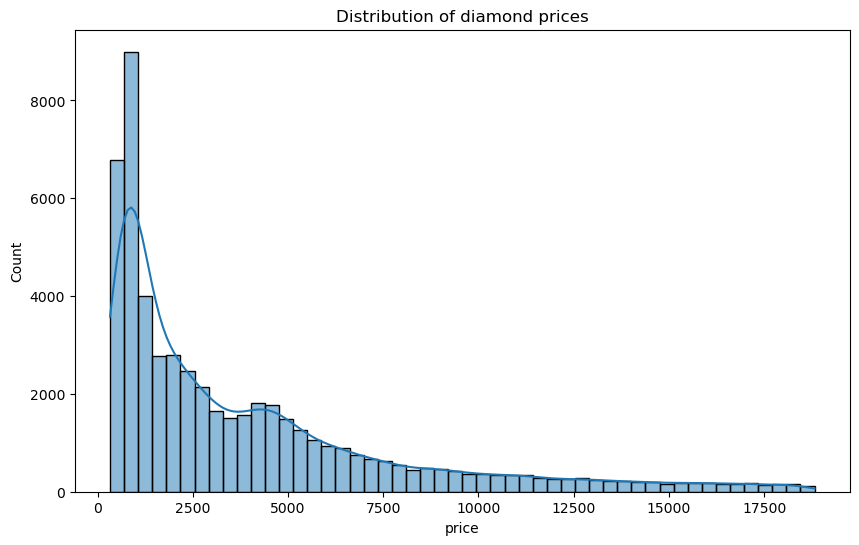

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(diamonds['price'], bins=50, kde=True)
plt.title("Distribution of diamond prices")
plt.show()

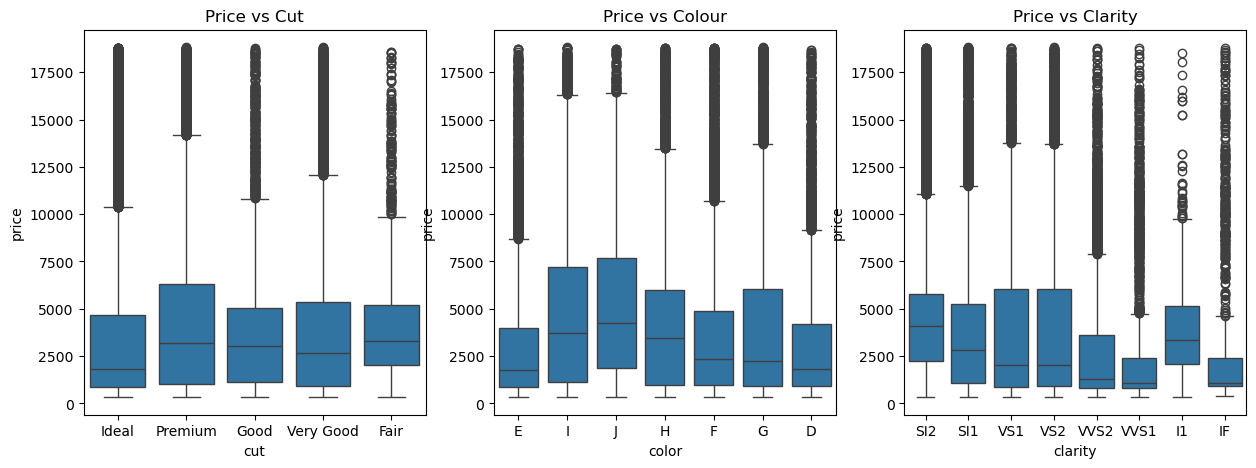

In [7]:
#price vs cut
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x = 'cut', y = 'price', data = diamonds)
plt.title('Price vs Cut')

#price vs color
plt.subplot(1, 3, 2)
sns.boxplot(x = 'color', y = 'price', data = diamonds)
plt.title('Price vs Colour')

#price vs clarity
plt.subplot(1, 3, 3)
sns.boxplot(x = 'clarity', y = 'price', data = diamonds)
plt.title('Price vs Clarity')
plt.show()

In [8]:
#preprocess
X1 = diamonds.drop(columns=['price', 'Unnamed: 0'])
Y1 = diamonds['price']

numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

#train
X_train, X_test, y_train, y_test = train_test_split(X1, Y1, test_size = 0.3, random_state = 309)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [9]:
#regression
models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors Regression": KNeighborsRegressor(),
    "Ridge Regression": Ridge(),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(),
    "Gradient Boosting Regression": GradientBoostingRegressor(),
    "SGD Regression": SGDRegressor(max_iter=1000, tol=1e-3),
    "SVR": SVR(),
    "Linear SVR": LinearSVR(max_iter=1000),
    "MLP Regression": MLPRegressor(max_iter=1000)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model

In [10]:
#CV
cv_results = {}
for name, model in trained_models.items():
    cv_score = cross_val_score(model, X_train_preprocessed, y_train, cv=5, scoring='r2')
    cv_results[name] = cv_score
    
cv_summary = {name: (np.mean(scores), np.std(scores)) for name, scores in cv_results.items()}
cv_df=pd.DataFrame(cv_summary, index=["Mean R2", "Std R2"]).T

cv_df

,Mean R2,Std R2
Linear Regression,0.919621,0.004063
K-Neighbors Regression,0.956584,0.001904
Ridge Regression,0.919657,0.004055
Decision Tree Regression,0.964057,0.001665
Random Forest Regression,0.979884,0.001205
Gradient Boosting Regression,0.965746,0.002202
SGD Regression,0.919531,0.003897
SVR,0.445064,0.002309
Linear SVR,0.839846,0.003602
MLP Regression,0.929044,0.098561


In [11]:
#assess on test data
test_results = {}

for name, model in trained_models.items():
    start_time = time.time()
    y_pred = model.predict(X_test_preprocessed)
    end_time = time.time() 
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    rse = (mse / np.var(y_test))
    execution_time = end_time - start_time
    test_results[name] = {'R2 Score': round(r2, 2), 'MSE': round(mse, 2), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'RSE': round(rse, 2), 'Execution Time (s)': round(execution_time, 2)}
    
#convert to df
test_results_df = pd.DataFrame(test_results).T

test_results_df

,R2 Score,MSE,MAE,RMSE,RSE,Execution Time (s)
Linear Regression,0.92,1324176.56,743.19,1150.73,0.08,0.00
K-Neighbors Regression,0.96,660521.13,415.94,812.72,0.04,7.31
Ridge Regression,0.92,1324229.91,743.18,1150.75,0.08,0.00
Decision Tree Regression,0.97,538927.03,354.76,734.12,0.03,0.01
Random Forest Regression,0.98,302303.37,272.69,549.82,0.02,0.38
Gradient Boosting Regression,0.97,553803.43,406.36,744.18,0.03,0.01
SGD Regression,0.92,1324371.52,748.36,1150.81,0.08,0.00
SVR,0.49,8313686.10,1373.55,2883.35,0.51,41.35
Linear SVR,0.85,2456619.03,819.48,1567.36,0.15,0.00
MLP Regression,0.98,322632.68,302.18,568.01,0.02,0.01
